In [1]:
import torch


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda:0


In [2]:
import os


# Object model and output paths
OBJ_FILENAME = "models/Guitar.obj"
OUTPUT_DIR = "./pose_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "frames"), exist_ok=True)

print("OBJ file:", OBJ_FILENAME)
print("Results folder:", OUTPUT_DIR)

OBJ file: models/Guitar.obj
Results folder: ./pose_results


In [3]:
# Load + decimate + normalize
import numpy as np
import open3d as o3d
from pytorch3d.io import load_obj
from pytorch3d.renderer import TexturesVertex
from pytorch3d.structures import Meshes


def load_and_decimate(obj_filename, device, target_faces=3000, gray=(0.7, 0.7, 0.7)):
    verts, faces, _ = load_obj(obj_filename, device='cpu')
    faces_idx = faces.verts_idx

    # Swap Y↔Z (guitar upright)
    verts = verts[:, [0, 2, 1]]

    # Decimation
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices  = o3d.utility.Vector3dVector(verts.numpy())
    o3d_mesh.triangles = o3d.utility.Vector3iVector(faces_idx.numpy())
    o3d_mesh = o3d_mesh.simplify_quadric_decimation(target_faces)

    verts     = torch.tensor(np.asarray(o3d_mesh.vertices), dtype=torch.float32)
    faces_idx = torch.tensor(np.asarray(o3d_mesh.triangles), dtype=torch.int64)
    print(f"Decimated → {faces_idx.shape[0]} faces")

    verts     = verts.to(device)
    faces_idx = faces_idx.to(device)

    verts_rgb = torch.ones_like(verts)[None]
    verts_rgb[..., 0] *= gray[0]
    verts_rgb[..., 1] *= gray[1]
    verts_rgb[..., 2] *= gray[2]

    mesh = Meshes(verts=[verts], faces=[faces_idx],
                  textures=TexturesVertex(verts_features=verts_rgb))
    return mesh


def normalize_mesh(mesh):
    verts  = mesh.verts_packed()
    center = verts.mean(0)
    scale  = torch.max(torch.norm(verts - center, dim=1)).item()
    mesh   = mesh.offset_verts(-center)
    mesh   = mesh.scale_verts(1.0 / scale)
    return mesh, center, scale


mesh, mesh_center, mesh_scale = normalize_mesh(
    load_and_decimate(OBJ_FILENAME, device, target_faces=3000)
)
print(f"Vertices: {mesh.verts_packed().shape[0]}, Faces: {mesh.faces_packed().shape[0]}")

v = mesh.verts_packed()
print("После нормализации:")
print(f"  Center: {v.mean(0).detach().cpu().numpy().round(3)}")
print(f"  Min/Max: {v.min().item():.3f} / {v.max().item():.3f}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/mad03633/Assign_2/graphics/lib/python3.10/site-packages/pytorch3d/io/obj_io.py:548: UserWarning: Mtl file does not exist: models/19361_Guitar_V1.mtl
  warnings.warn(f"Mtl file does not exist: {f}")


Decimated → 3000 faces
Vertices: 1530, Faces: 3000
После нормализации:
  Center: [ 0. -0. -0.]
  Min/Max: -0.432 / 0.949


In [4]:
from pytorch3d.vis.plotly_vis import plot_scene 


fig = plot_scene(
    { "Meshes": { 
        "Original OBJ": mesh 
        } 
    }) 

fig.show()

X range: -0.332 to 0.342
Y range: -0.432 to 0.949
Z range: -0.057 to 0.166


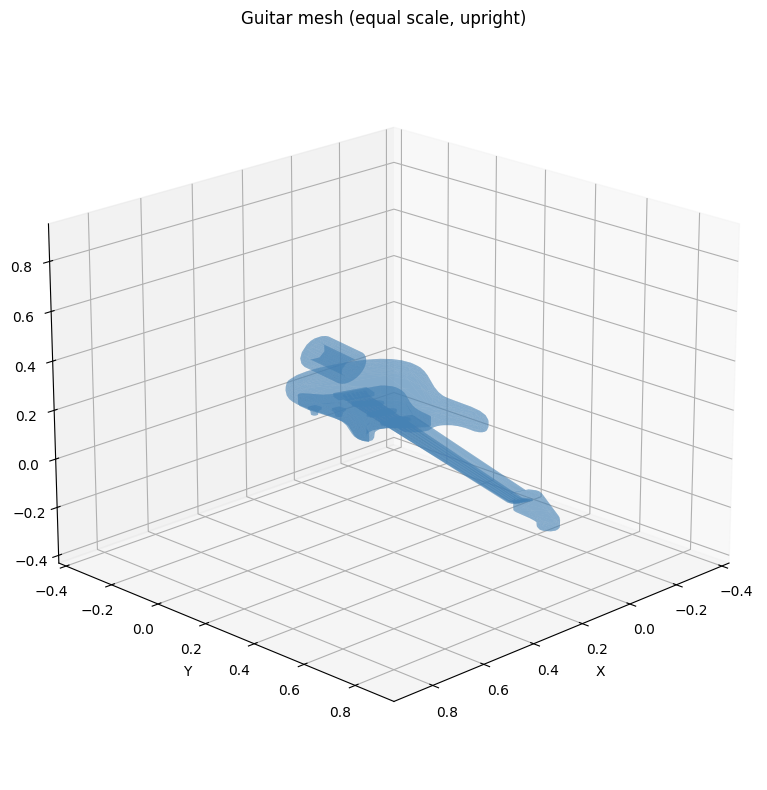

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
 
verts_np = mesh.verts_packed().detach().cpu().numpy()
faces_np = mesh.faces_packed().detach().cpu().numpy()
 
print("X range:", verts_np[:,0].min().round(3), "to", verts_np[:,0].max().round(3))
print("Y range:", verts_np[:,1].min().round(3), "to", verts_np[:,1].max().round(3))
print("Z range:", verts_np[:,2].min().round(3), "to", verts_np[:,2].max().round(3))
 
idx  = np.random.choice(len(faces_np), min(3000, len(faces_np)), replace=False)
fig  = plt.figure(figsize=(8, 8))
ax   = fig.add_subplot(111, projection='3d')
poly = Poly3DCollection(verts_np[faces_np[idx]], alpha=0.4,
                        facecolor='steelblue', edgecolor='none')
ax.add_collection3d(poly)
 
# Equal scale on all axes
all_v = np.concatenate([verts_np[:,0], verts_np[:,1], verts_np[:,2]])
vmin, vmax = all_v.min(), all_v.max()
ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax); ax.set_zlim(vmin, vmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Guitar mesh (equal scale, upright)')
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

In [6]:
print("Number of vertices:", mesh.verts_packed().shape[0])
print("Number of faces:", mesh.faces_packed().shape[0])

Number of vertices: 1530
Number of faces: 3000


In [7]:
# Renderer settings
import numpy as np
from pytorch3d.renderer import BlendParams, RasterizationSettings, PointLights

image_size = 128
sigma = 1e-4
gamma = 1e-4
faces_per_pixel = 10

blend_params = BlendParams(sigma=sigma, gamma=gamma)

raster_settings_silhouette = RasterizationSettings(
    image_size=image_size,
    blur_radius=np.log(1. / 1e-4 - 1.) * sigma,
    faces_per_pixel=faces_per_pixel,
)
raster_settings_rgb = RasterizationSettings(
    image_size=image_size,
    blur_radius=0.0,
    faces_per_pixel=1,
)

lights = PointLights(device=device, location=[[2.0, 2.0, -2.0]])
print(f"image_size={image_size}, sigma={sigma}, faces_per_pixel={faces_per_pixel}")

image_size=128, sigma=0.0001, faces_per_pixel=10


In [8]:
from pytorch3d.renderer import (
    look_at_rotation
)


# Camera Position
def camera_position_to_RT(camera_position, device):
    R = look_at_rotation(camera_position[None, :], device=device)
    T = -torch.bmm(R.transpose(1, 2), camera_position[None, :, None])[:, :, 0]
    return R, T

In [9]:
from pytorch3d.renderer import (
    MeshRenderer,
    MeshRasterizer,
    FoVPerspectiveCameras,
    SoftSilhouetteShader,
    HardPhongShader
)

cameras = FoVPerspectiveCameras(device=device)

# Silhouette and RGB renderer
silhouette_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteShader(blend_params=blend_params)
)

rgb_renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=cameras,
        raster_settings=raster_settings_rgb
    ),
    shader=HardPhongShader(device=device, cameras=cameras, lights=lights)
)

In [10]:
def render_silhouette(mesh, camera_position):
    R, T = camera_position_to_RT(camera_position, device)
    image = silhouette_renderer(meshes_world=mesh, R=R, T=T)
    return image

def render_rgb(mesh, camera_position):
    R, T = camera_position_to_RT(camera_position, device)
    image = rgb_renderer(meshes_world=mesh, R=R, T=T)
    return image

Non-zero silhouette pixels: 969


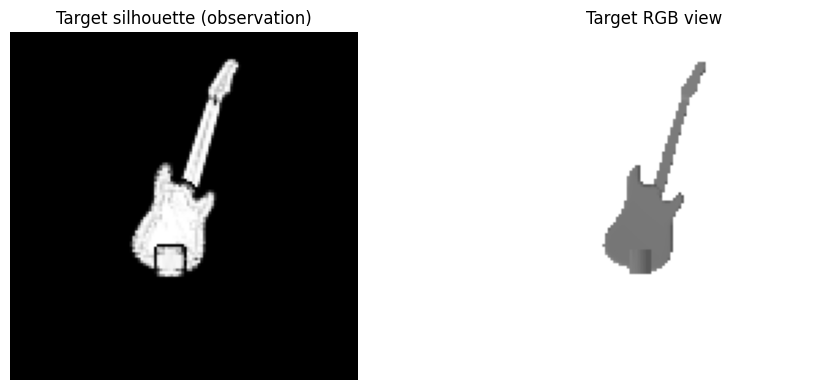

In [11]:
import matplotlib.pyplot as plt
 

# Target camera — placed so the guitar is clearly visible
camera_target = torch.tensor([0.0, 0.0, 2.0], dtype=torch.float32, device=device)
 
with torch.no_grad():
    target_silhouette = render_silhouette(mesh, camera_target)
    target_rgb = render_rgb(mesh, camera_target)
 
target_alpha  = target_silhouette[0, ..., 3].detach().cpu().numpy()
target_rgb_np = target_rgb[0, ..., :3].detach().cpu().numpy()
 
print("Non-zero silhouette pixels:", (target_alpha > 0.5).sum())
 
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(target_alpha, cmap="gray")
plt.title("Target silhouette (observation)")
plt.axis("off")
 
plt.subplot(1, 2, 2)
plt.imshow(target_rgb_np.clip(0, 1))
plt.title("Target RGB view")
plt.axis("off")
 
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target.png"), dpi=150)
plt.show()

In [12]:
plt.imsave(os.path.join(OUTPUT_DIR, "target_silhouette.png"), target_alpha, cmap="gray")
plt.imsave(os.path.join(OUTPUT_DIR, "target_rgb.png"), target_rgb_np)
print("Target images saved")

Target images saved


In [13]:
import torch
import torch.nn as nn


# Class model
class Model(nn.Module):
    def __init__(self, meshes, image_ref, init_camera_position, device):
        super().__init__()

        self.meshes = meshes
        self.image_ref = image_ref
        self.device = device

        self.camera_position = nn.Parameter(
            torch.tensor(init_camera_position, dtype=torch.float32, device=device)
        )

    def forward(self):
        image = render_silhouette(self.meshes, self.camera_position)

        pred = image[..., 3]
        ref = self.image_ref[..., 3]

        loss = torch.mean((pred - ref) ** 2)

        return loss, image

In [14]:
# Initial camera position far from target
model = Model(
    meshes=mesh,
    image_ref=target_silhouette,
    init_camera_position=[2.5, -1.5, 3.0],
    device=device
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

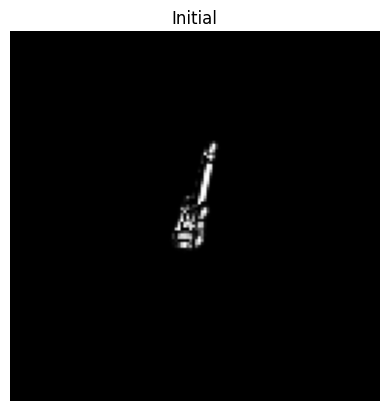

In [15]:
# Initial view
with torch.no_grad():
    init_sil = render_silhouette(mesh, model.camera_position)

plt.imshow(init_sil[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title("Initial")
plt.axis("off")
plt.show()

In [16]:
# Optimization
loss_history = []

for i in range(200):
    optimizer.zero_grad()

    loss, _ = model()

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if i % 20 == 0:
        print(i, loss.item())

0 0.043646808713674545
20 0.028819885104894638
40 0.001875824062153697
60 0.0010430826805531979
80 0.00013866521476302296
100 0.00020799983758479357
120 0.00013035759911872447
140 3.678421853692271e-05
160 0.00011383391392882913
180 9.918370051309466e-05


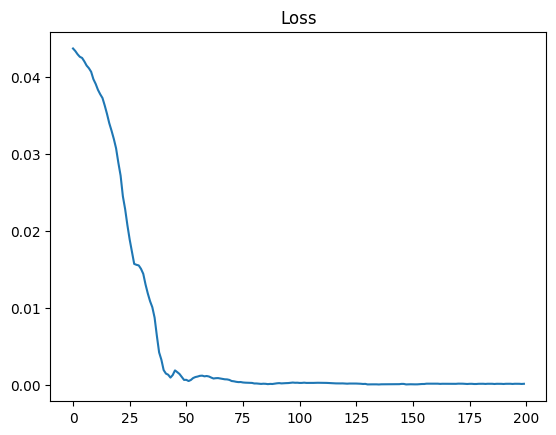

In [17]:
# Loss plot
plt.plot(loss_history)
plt.title("Loss")
plt.show()

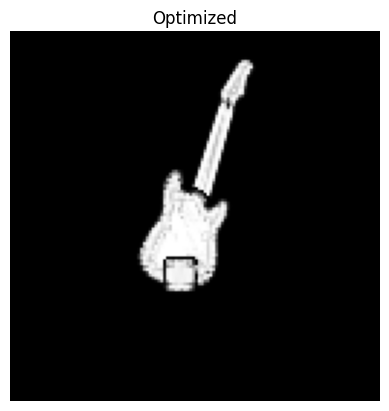

In [18]:
# Final result
with torch.no_grad():
    final_sil = render_silhouette(mesh, model.camera_position)

plt.imshow(final_sil[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title("Optimized")
plt.axis("off")
plt.show()

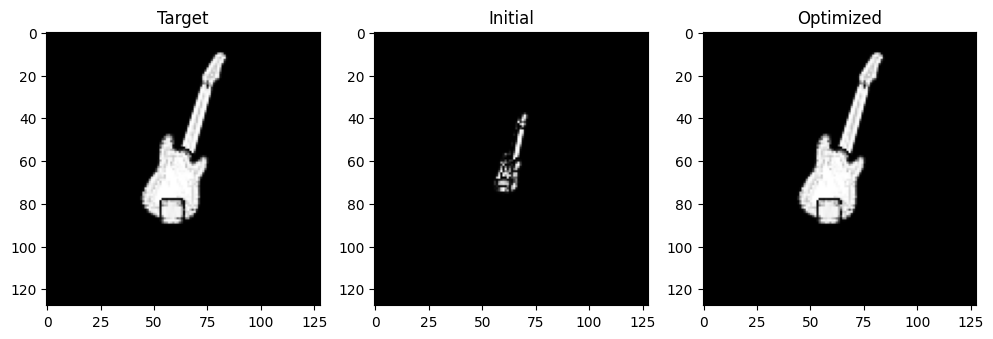

In [19]:
# Compare
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(target_silhouette[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title("Target")

plt.subplot(1,3,2)
plt.imshow(init_sil[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title("Initial")

plt.subplot(1,3,3)
plt.imshow(final_sil[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title("Optimized")

plt.show()

In [20]:
print("Target:", camera_target.cpu().numpy())
print("Optimized:", model.camera_position.detach().cpu().numpy())

Target: [0. 0. 2.]
Optimized: [ 0.00523692 -0.00365807  1.9984537 ]


Additional Visualizations as in book

In [21]:
import matplotlib.pyplot as plt
import os

frames_dir = os.path.join(OUTPUT_DIR, "frames")
os.makedirs(frames_dir, exist_ok=True)

num_iterations = 200

for i in range(num_iterations):
    optimizer.zero_grad()

    loss, pred_image = model()

    loss.backward()
    optimizer.step()

    if i % 10 == 0:
        print(f"iter: {i}, loss: {loss.item():.4f}")

        sil = pred_image[0, ..., 3].detach().cpu().numpy()

        plt.figure(figsize=(4, 4))
        plt.imshow(sil, cmap="gray")
        plt.title(f"iter: {i}, loss: {loss.item():.2f}")
        plt.axis("off")

        plt.savefig(os.path.join(frames_dir, f"iter_{i:04d}.png"),
                    bbox_inches='tight', dpi=120)
        plt.close()

iter: 0, loss: 0.0001
iter: 10, loss: 0.0001
iter: 20, loss: 0.0001
iter: 30, loss: 0.0001
iter: 40, loss: 0.0001
iter: 50, loss: 0.0001
iter: 60, loss: 0.0001
iter: 70, loss: 0.0001
iter: 80, loss: 0.0001
iter: 90, loss: 0.0001
iter: 100, loss: 0.0001
iter: 110, loss: 0.0001
iter: 120, loss: 0.0001
iter: 130, loss: 0.0001
iter: 140, loss: 0.0001
iter: 150, loss: 0.0001
iter: 160, loss: 0.0001
iter: 170, loss: 0.0001
iter: 180, loss: 0.0001
iter: 190, loss: 0.0001


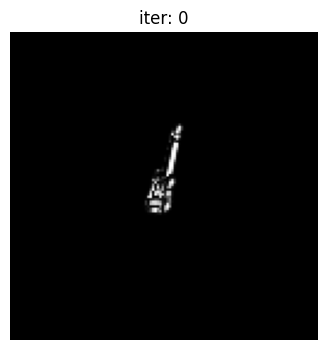

In [22]:
with torch.no_grad():
    init_sil = render_silhouette(mesh, torch.tensor([2.5, -1.5, 3.0], device=device))

plt.figure(figsize=(4, 4))
plt.imshow(init_sil[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title("iter: 0")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "initial.png"), dpi=150)
plt.show()

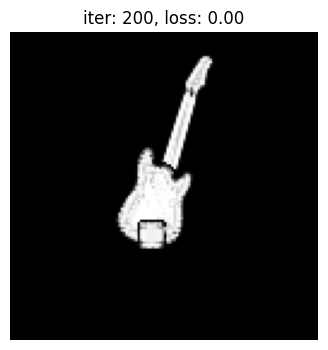

In [23]:
with torch.no_grad():
    final_sil = render_silhouette(mesh, model.camera_position)

plt.figure(figsize=(4, 4))
plt.imshow(final_sil[0, ..., 3].cpu().numpy(), cmap="gray")
plt.title(f"iter: {num_iterations}, loss: {loss.item():.2f}")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "final.png"), dpi=150)
plt.show()